# Оценка и визуализация

Confusion matrix, ROC, важность признаков (RF). **Запуск после 03 и 04** (`ml_ready.joblib`, `trained_models.joblib`).

Если файлов моделей нет, ноутбук переобучит модели на тех же данных.

**Colab:** [colab_quickstart.ipynb](colab_quickstart.ipynb); при необходимости `%cd /content/water-quality-ee`.

**Для новичков:** расшифровка метрик и графиков — [`results/INSIGHTS.md`](../results/INSIGHTS.md).


### Пояснение для начинающих (первые три кодовые ячейки)

1. **Импорты** — путь к проекту, загрузка сохранённых данных и функций визуализации.
2. **Загрузка + оценка** — читаем `ml_ready.joblib`; если есть `trained_models.joblib`, подставляем готовые модели, иначе **кратко переобучаем** LR и RF на train и считаем метрики на test.
3. **Сводная таблица** — то же `compare_models`, что в ноутбуке 04.

**Инсайт:** цифры здесь должны **совпадать** с 04 при наличии сохранённых моделей и того же `ml_ready.joblib`.

In [1]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

def _project_root() -> Path:
    spec = importlib.util.find_spec('data_loader')
    if spec is not None and getattr(spec, 'origin', None):
        cand = Path(spec.origin).resolve().parent.parent
        if (cand / 'data' / 'raw').is_dir() or (cand / 'src' / 'data_loader.py').is_file():
            return cand
    env = os.environ.get('WATER_QUALITY_EE_ROOT', '').strip()
    if env:
        p = Path(env).expanduser().resolve()
        if (p / 'src' / 'data_loader.py').is_file():
            return p
    cwd = Path.cwd().resolve()
    try:
        r = subprocess.run(
            ['git', 'rev-parse', '--show-toplevel'],
            cwd=cwd, capture_output=True, text=True, timeout=15,
        )
        if r.returncode == 0 and r.stdout.strip():
            p = Path(r.stdout.strip()).resolve()
            if (p / 'src' / 'data_loader.py').is_file():
                return p
    except (FileNotFoundError, OSError, subprocess.TimeoutExpired):
        pass
    for root in [cwd, *list(cwd.parents)[:28]]:
        if (root / 'src' / 'data_loader.py').is_file():
            return root
    raise RuntimeError('См. 01: pip install -e . или корректный WATER_QUALITY_EE_ROOT.')

if importlib.util.find_spec('data_loader') is None:
    sys.path.insert(0, str(_project_root() / 'src'))

import data_loader
ROOT = Path(data_loader.__file__).resolve().parent.parent

import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from evaluate import (
    evaluate_model,
    compare_models,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_feature_importance,
)

In [2]:
data_path = ROOT / 'data' / 'processed' / 'ml_ready.joblib'
models_path = ROOT / 'data' / 'processed' / 'trained_models.joblib'

if not data_path.exists():
    raise FileNotFoundError(f'Нет {data_path}. Запустите 03_preprocessing.ipynb')

b = joblib.load(data_path)
X_train, X_test = b['X_train'], b['X_test']
y_train, y_test = b['y_train'], b['y_test']
feature_names = b['feature_names']

if models_path.exists():
    pack = joblib.load(models_path)
    lr, rf = pack['lr'], pack['rf']
else:
    lr = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
    lr.fit(X_train, y_train)
    rf = RandomForestClassifier(
        n_estimators=200, max_depth=12, class_weight='balanced',
        random_state=42, n_jobs=-1,
    )
    rf.fit(X_train, y_train)

res_lr = evaluate_model(lr, X_test, y_test, model_name='Logistic Regression')
res_rf = evaluate_model(rf, X_test, y_test, model_name='Random Forest')


Модель: Logistic Regression
               precision    recall  f1-score   support

Нарушение (0)       0.44      0.81      0.57       548
    Норма (1)       0.98      0.92      0.95      7171

     accuracy                           0.91      7719
    macro avg       0.71      0.87      0.76      7719
 weighted avg       0.95      0.91      0.92      7719

ROC-AUC: 0.9241

Модель: Random Forest
               precision    recall  f1-score   support

Нарушение (0)       0.88      0.91      0.89       548
    Норма (1)       0.99      0.99      0.99      7171

     accuracy                           0.98      7719
    macro avg       0.94      0.95      0.94      7719
 weighted avg       0.98      0.98      0.98      7719

ROC-AUC: 0.9852


In [3]:
compare_models([res_lr, res_rf])

,Accuracy,Precision (нарушение),Recall (нарушение),F1 (нарушение),ROC-AUC
Модель,,,,,
Logistic Regression,0.9127,0.4380,0.8120,0.5691,0.9241
Random Forest,0.9846,0.8796,0.9069,0.8931,0.9852


## Confusion matrices

### Пояснение для начинающих
- **Матрица ошибок** 2×2: факт (строки) vs предсказание (столбцы).
- Для класса **нарушение (0)** важна ячейка **false negative**: вода плохая, а модель сказала «норма».

### Результат раздела (инсайт)
Наглядно видно, «где модель лжёт» чаще — полезно для презентации и курсовой.

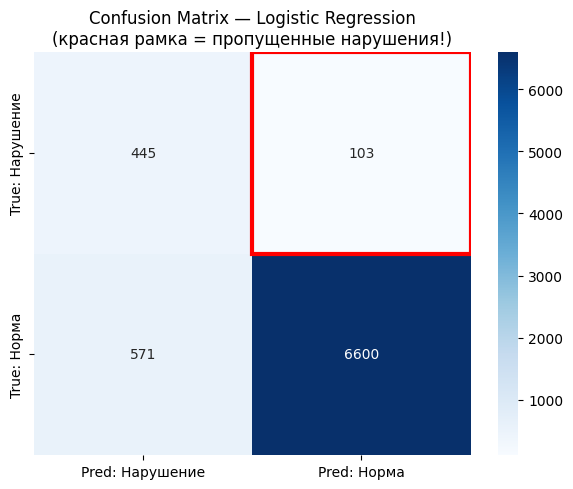

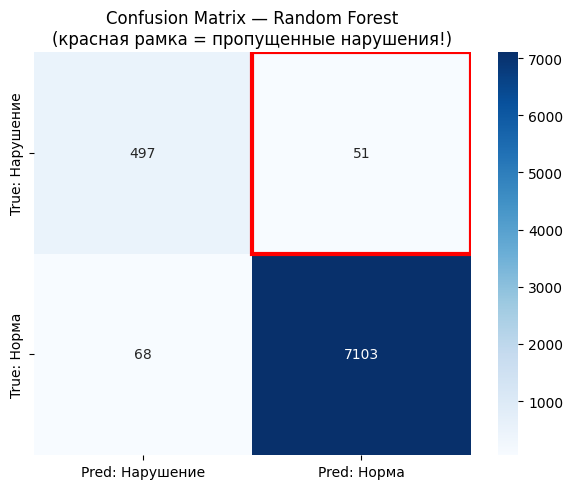

In [4]:
plot_confusion_matrix(y_test, res_lr['y_pred'], model_name='Logistic Regression')
plot_confusion_matrix(y_test, res_rf['y_pred'], model_name='Random Forest')

## ROC (красная рамка в CM — пропущенные нарушения = FN)

### Пояснение для начинающих
- **ROC-кривая** показывает компромисс между долей найденных нарушений и долей ложных тревог при переборе порога вероятности.
- **AUC** — интегральная оценка качества ранжирования; чем выше, тем лучше модель отделяет классы.

### Результат раздела (инсайт)
Сравнение LR и RF на одном графике; RF обычно выше по AUC на этих признаках.

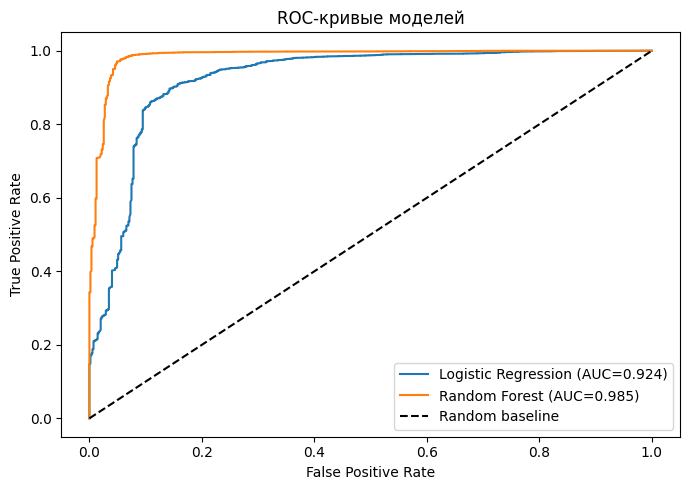

In [5]:
plot_roc_curve([res_lr, res_rf])

## Важность признаков (Random Forest)

### Пояснение для начинающих
- Random Forest для каждого признака считает, **насколько он в среднем уменьшал ошибку** при разбиениях деревьев (упрощённо: «насколько часто и сильно использовали»).
- Это **не причинность**: высокий вес ≠ доказанное влияние на здоровье.

### Результат раздела (инсайт)
Список топ-признаков для обсуждения в отчёте и идей для следующего EDA.

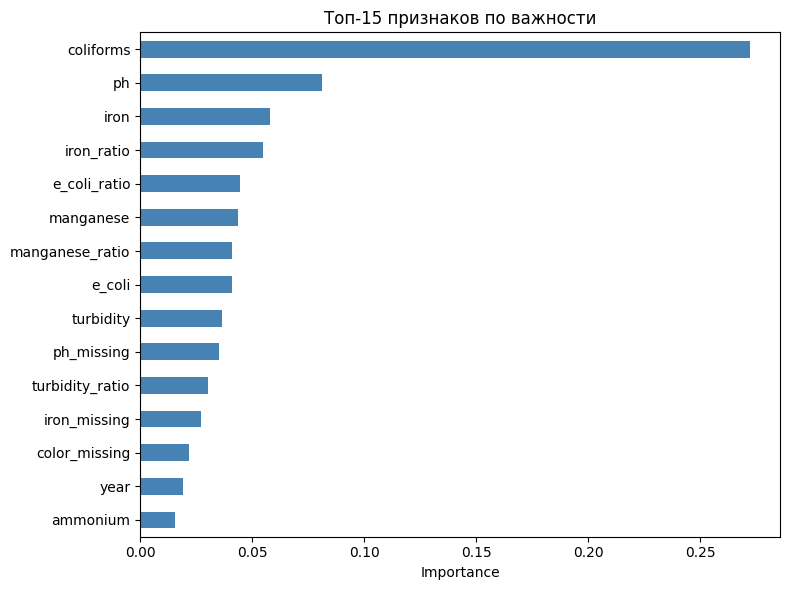

In [ ]:
plot_feature_importance(rf, feature_names, top_n=15)